In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.3.3
NumPy version: 2.2.6


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/raw/healthcare_disease_risk.csv")

df.head()

,Age,Gender,BMI,BloodPressure,Cholesterol,Glucose,Smoking,PhysicalActivity,FamilyHistory,HeartRate,Disease_Risk
0,56,Male,39.3,96,164,111,No,Medium,No,78,0
1,69,Male,22.0,157,177,137,Yes,Medium,Yes,64,1
2,46,Male,18.5,108,298,139,Yes,Medium,Yes,67,1
3,32,Female,33.8,120,245,147,Yes,Medium,No,98,1
4,60,Female,27.2,124,281,159,No,Medium,Yes,93,1


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 11


In [6]:
print(df.columns.tolist())

['Age', 'Gender', 'BMI', 'BloodPressure', 'Cholesterol', 'Glucose', 'Smoking', 'PhysicalActivity', 'FamilyHistory', 'HeartRate', 'Disease_Risk']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2000 non-null   int64  
 1   Gender            2000 non-null   object 
 2   BMI               2000 non-null   float64
 3   BloodPressure     2000 non-null   int64  
 4   Cholesterol       2000 non-null   int64  
 5   Glucose           2000 non-null   int64  
 6   Smoking           2000 non-null   object 
 7   PhysicalActivity  2000 non-null   object 
 8   FamilyHistory     2000 non-null   object 
 9   HeartRate         2000 non-null   int64  
 10  Disease_Risk      2000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 172.0+ KB


In [8]:
df.describe()

,Age,BMI,BloodPressure,Cholesterol,Glucose,HeartRate,Disease_Risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.114000,29.112450,135.213000,208.831500,143.750000,86.877500,0.732000
std,17.926564,6.332941,26.027185,51.105508,42.753005,18.987753,0.443028
min,18.000000,18.000000,90.000000,120.000000,70.000000,55.000000,0.000000
25%,34.000000,23.600000,112.000000,164.000000,107.000000,70.000000,0.000000
50%,49.000000,29.300000,135.000000,209.000000,143.000000,87.000000,1.000000
75%,65.000000,34.625000,158.000000,252.000000,181.000000,104.000000,1.000000
max,79.000000,40.000000,179.000000,299.000000,219.000000,119.000000,1.000000


In [9]:
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
BloodPressure       0
Cholesterol         0
Glucose             0
Smoking             0
PhysicalActivity    0
FamilyHistory       0
HeartRate           0
Disease_Risk        0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
print(df["Disease_Risk"].value_counts())

Disease_Risk
1    1464
0     536
Name: count, dtype: int64


In [12]:
print(df["Disease_Risk"].value_counts(normalize=True) * 100)

Disease_Risk
1    73.2
0    26.8
Name: proportion, dtype: float64


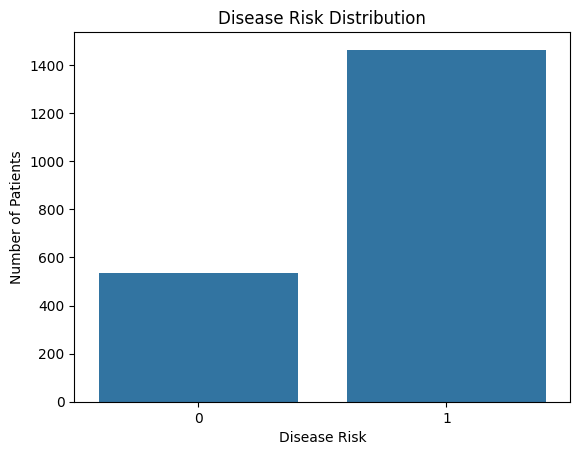

In [13]:
sns.countplot(x="Disease_Risk", data=df)

plt.title("Disease Risk Distribution")
plt.xlabel("Disease Risk")
plt.ylabel("Number of Patients")
plt.show()

In [14]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Smoking', 'PhysicalActivity', 'FamilyHistory'], dtype='object')

In [15]:
df.select_dtypes(include=np.number).columns

Index(['Age', 'BMI', 'BloodPressure', 'Cholesterol', 'Glucose', 'HeartRate',
       'Disease_Risk'],
      dtype='object')

In [16]:
print("Missing values before:")
print(df.isnull().sum())

Missing values before:
Age                 0
Gender              0
BMI                 0
BloodPressure       0
Cholesterol         0
Glucose             0
Smoking             0
PhysicalActivity    0
FamilyHistory       0
HeartRate           0
Disease_Risk        0
dtype: int64


In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

In [18]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [19]:
print("Missing values after:")
print(df.isnull().sum())

Missing values after:
Age                 0
Gender              0
BMI                 0
BloodPressure       0
Cholesterol         0
Glucose             0
Smoking             0
PhysicalActivity    0
FamilyHistory       0
HeartRate           0
Disease_Risk        0
dtype: int64


In [20]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [21]:
X = df.drop("Disease_Risk", axis=1)
y = df["Disease_Risk"]

In [22]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 10)
Target shape: (2000,)


In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X.head()

,Age,BMI,BloodPressure,Cholesterol,Glucose,HeartRate,Gender_Male,Smoking_Yes,PhysicalActivity_Low,PhysicalActivity_Medium,FamilyHistory_Yes
0,56,39.3,96,164,111,78,True,False,False,True,False
1,69,22.0,157,177,137,64,True,True,False,True,True
2,46,18.5,108,298,139,67,True,True,False,True,True
3,32,33.8,120,245,147,98,False,True,False,True,False
4,60,27.2,124,281,159,93,False,False,False,True,True


In [25]:
print("Final number of features:", X.shape[1])
print(X.columns.tolist())

Final number of features: 11
['Age', 'BMI', 'BloodPressure', 'Cholesterol', 'Glucose', 'HeartRate', 'Gender_Male', 'Smoking_Yes', 'PhysicalActivity_Low', 'PhysicalActivity_Medium', 'FamilyHistory_Yes']


In [26]:
processed_data = X.copy()
processed_data["Disease_Risk"] = y

processed_data.to_csv(
    "../data/processed/healthcare_disease_risk_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/healthcare_disease_risk.csv")

df.head()

,Age,Gender,BMI,BloodPressure,Cholesterol,Glucose,Smoking,PhysicalActivity,FamilyHistory,HeartRate,Disease_Risk
0,56,Male,39.3,96,164,111,No,Medium,No,78,0
1,69,Male,22.0,157,177,137,Yes,Medium,Yes,64,1
2,46,Male,18.5,108,298,139,Yes,Medium,Yes,67,1
3,32,Female,33.8,120,245,147,Yes,Medium,No,98,1
4,60,Female,27.2,124,281,159,No,Medium,Yes,93,1


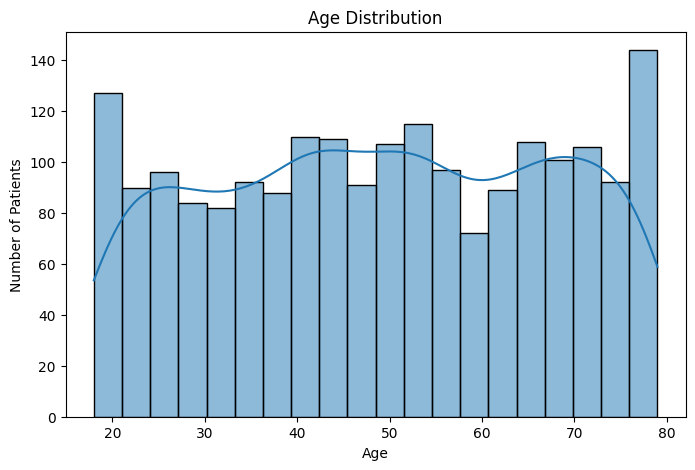

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

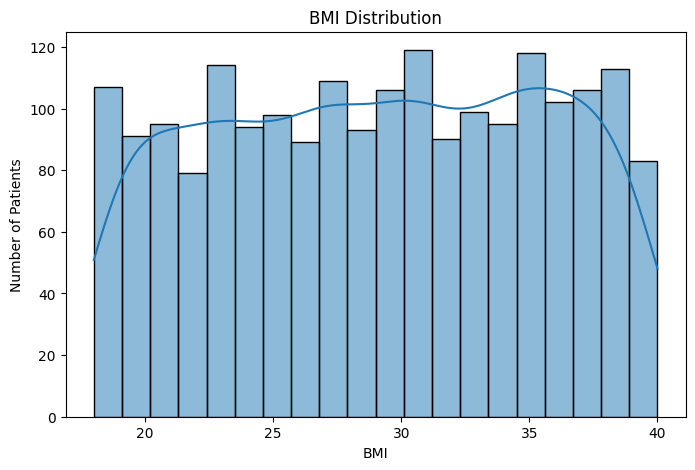

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(df["BMI"], bins=20, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.show()

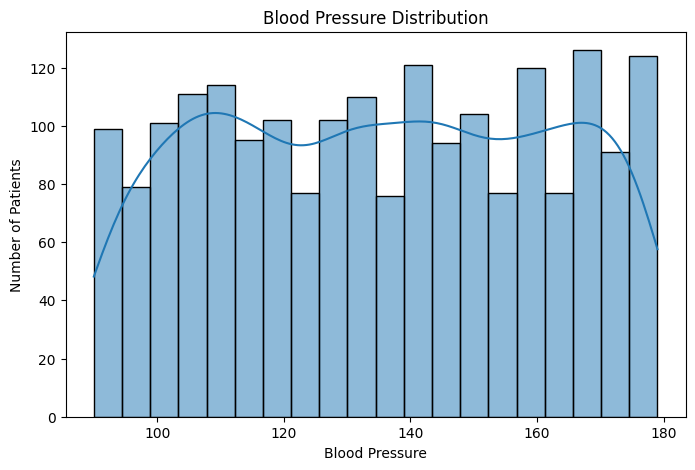

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(df["BloodPressure"], bins=20, kde=True)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

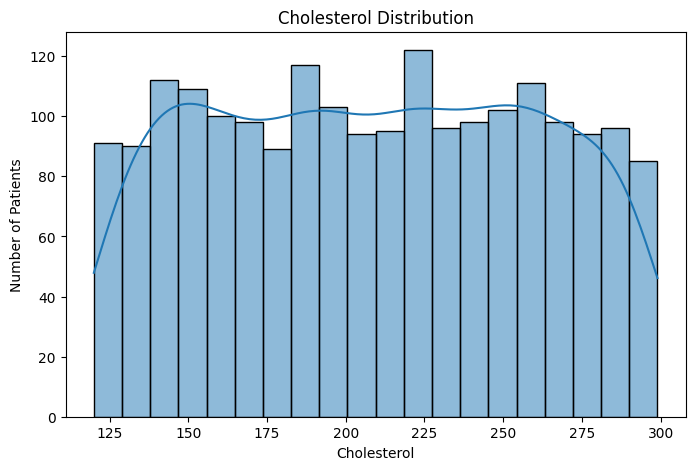

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Cholesterol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")
plt.show()

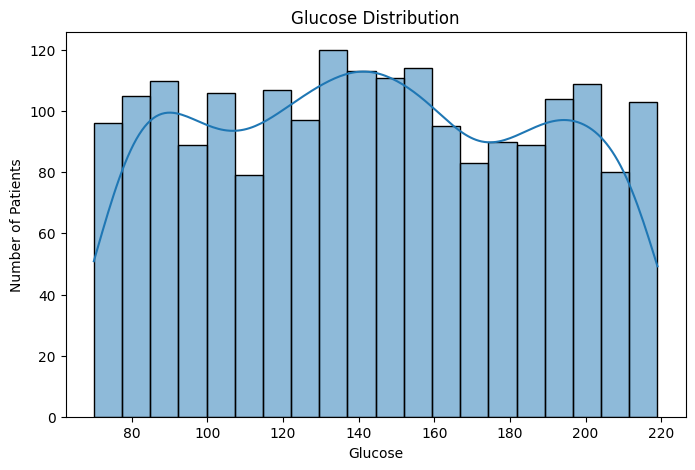

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Glucose"], bins=20, kde=True)

plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.show()

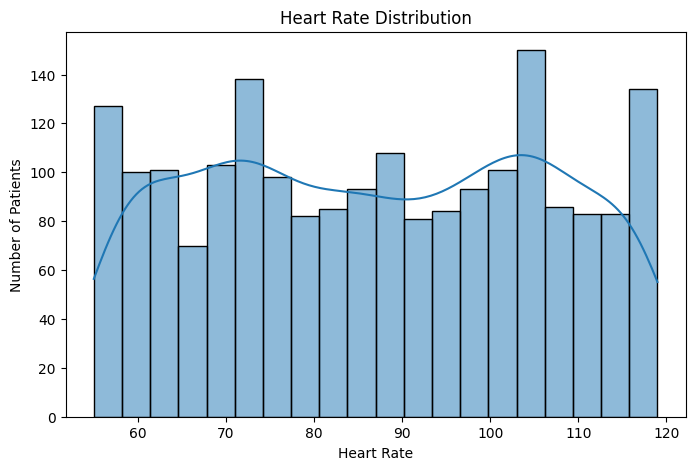

In [45]:
plt.figure(figsize=(8, 5))

sns.histplot(df["HeartRate"], bins=20, kde=True)

plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate")
plt.ylabel("Number of Patients")
plt.show()

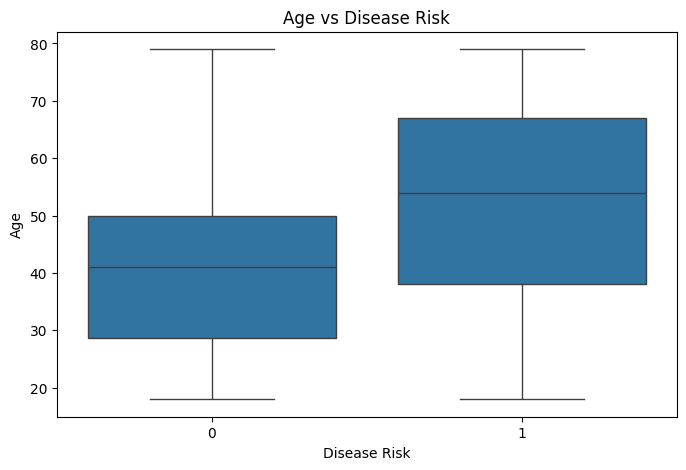

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Disease_Risk",
    y="Age",
    data=df
)

plt.title("Age vs Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Age")
plt.show()

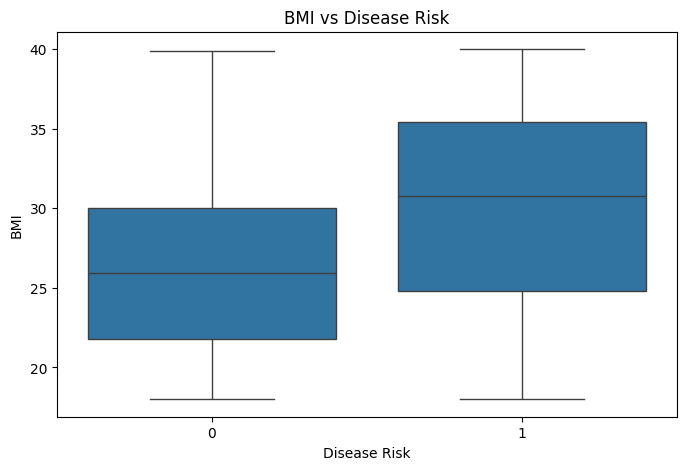

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Disease_Risk",
    y="BMI",
    data=df
)

plt.title("BMI vs Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("BMI")
plt.show()

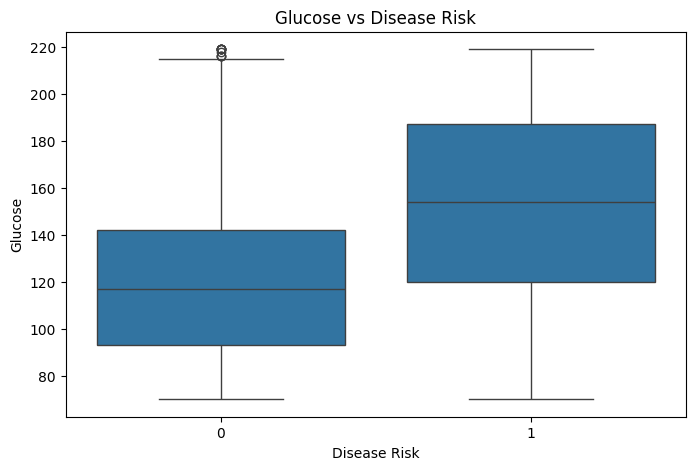

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Disease_Risk",
    y="Glucose",
    data=df
)

plt.title("Glucose vs Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Glucose")
plt.show()

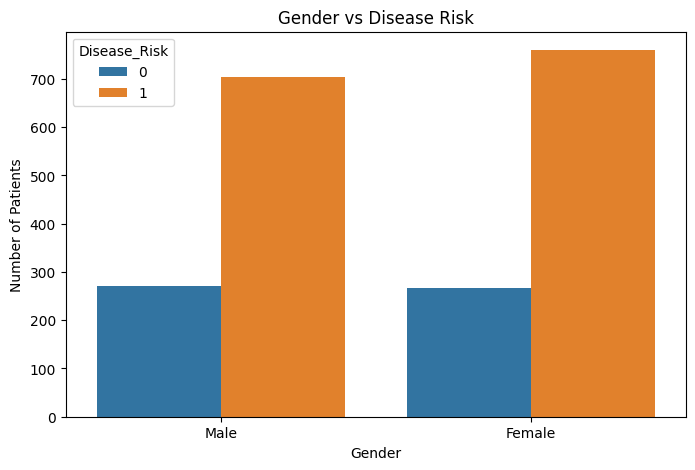

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Gender",
    hue="Disease_Risk",
    data=df
)

plt.title("Gender vs Disease Risk")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

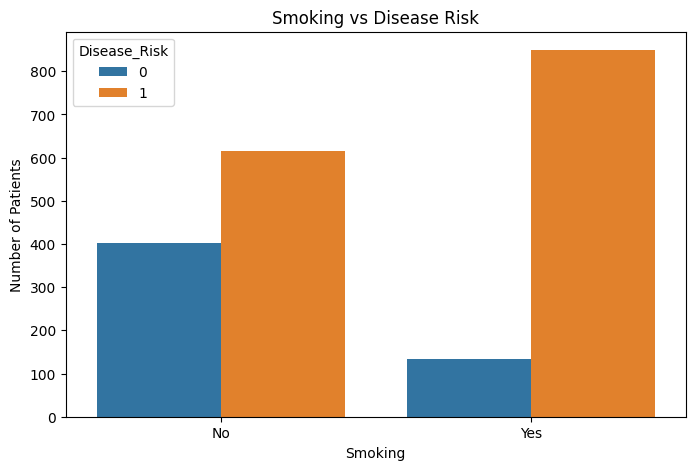

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Smoking",
    hue="Disease_Risk",
    data=df
)

plt.title("Smoking vs Disease Risk")
plt.xlabel("Smoking")
plt.ylabel("Number of Patients")

plt.show()

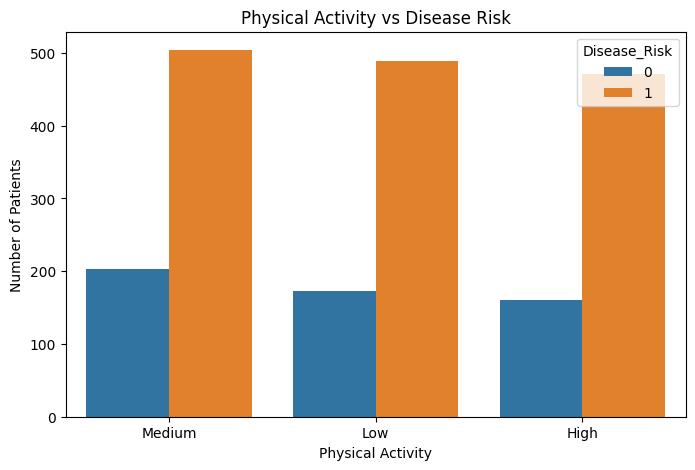

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="PhysicalActivity",
    hue="Disease_Risk",
    data=df
)

plt.title("Physical Activity vs Disease Risk")
plt.xlabel("Physical Activity")
plt.ylabel("Number of Patients")

plt.show()

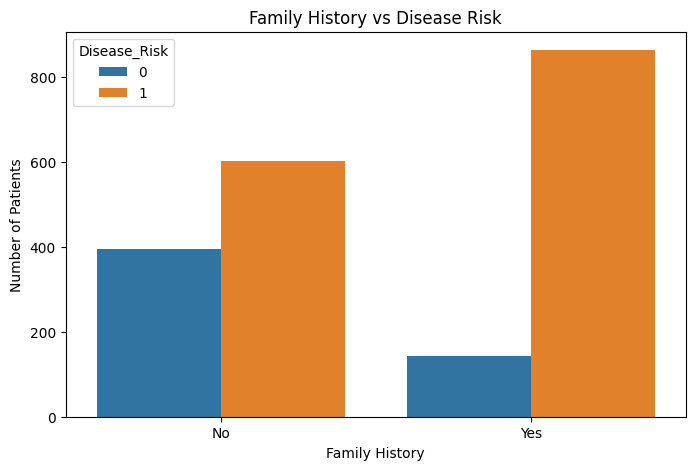

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="FamilyHistory",
    hue="Disease_Risk",
    data=df
)

plt.title("Family History vs Disease Risk")
plt.xlabel("Family History")
plt.ylabel("Number of Patients")

plt.show()

In [53]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

print(correlation)

                    Age       BMI  BloodPressure  Cholesterol   Glucose  \
Age            1.000000 -0.006510      -0.014543     0.014523  0.004682   
BMI           -0.006510  1.000000       0.005786     0.021264 -0.008813   
BloodPressure -0.014543  0.005786       1.000000    -0.014794 -0.000886   
Cholesterol    0.014523  0.021264      -0.014794     1.000000  0.006112   
Glucose        0.004682 -0.008813      -0.000886     0.006112  1.000000   
HeartRate     -0.007125  0.006088      -0.004310     0.042052  0.019768   
Disease_Risk   0.239991  0.247208       0.239747     0.252734  0.281227   

               HeartRate  Disease_Risk  
Age            -0.007125      0.239991  
BMI             0.006088      0.247208  
BloodPressure  -0.004310      0.239747  
Cholesterol     0.042052      0.252734  
Glucose         0.019768      0.281227  
HeartRate       1.000000      0.043432  
Disease_Risk    0.043432      1.000000  


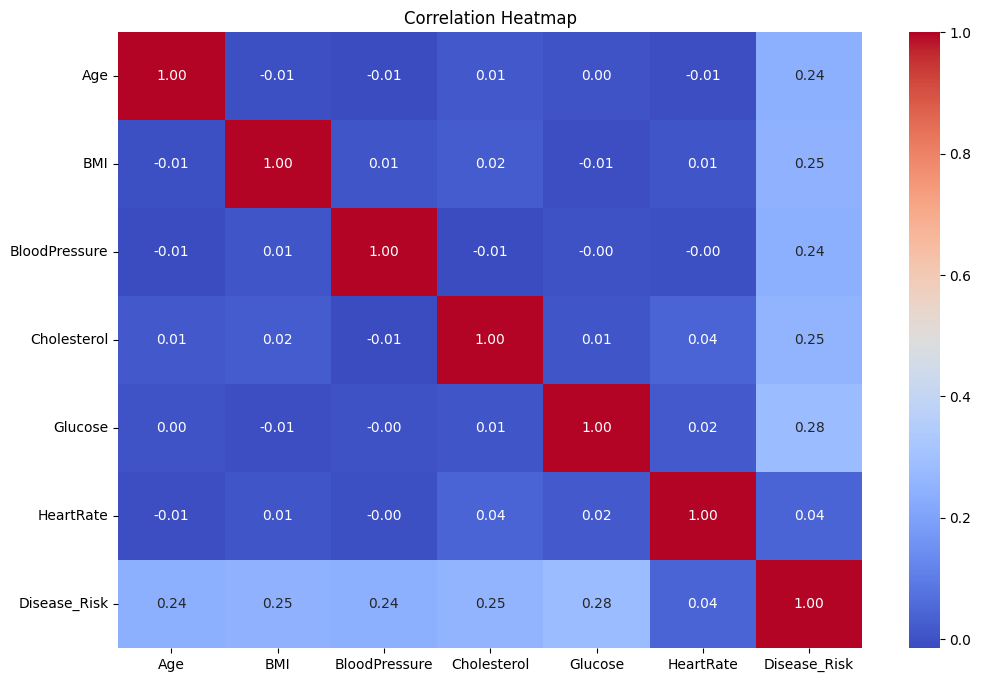

In [54]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [55]:
risk_correlation = correlation["Disease_Risk"].sort_values(
    ascending=False
)

print(risk_correlation)

Disease_Risk     1.000000
Glucose          0.281227
Cholesterol      0.252734
BMI              0.247208
Age              0.239991
BloodPressure    0.239747
HeartRate        0.043432
Name: Disease_Risk, dtype: float64


In [56]:
numeric_columns = [
    "Age",
    "BMI",
    "BloodPressure",
    "Cholesterol",
    "Glucose",
    "HeartRate"
]

print(numeric_columns)

['Age', 'BMI', 'BloodPressure', 'Cholesterol', 'Glucose', 'HeartRate']


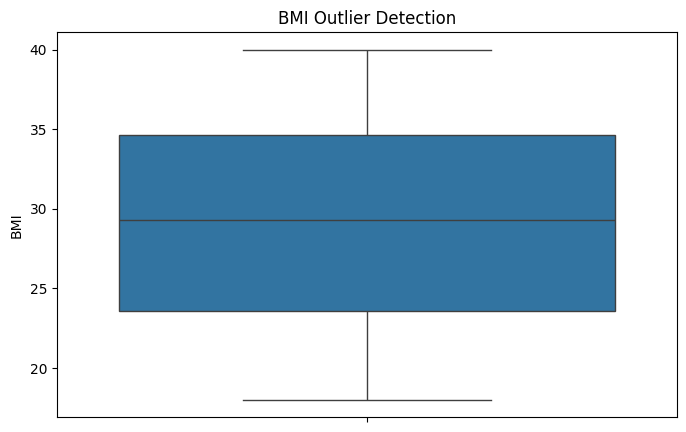

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["BMI"])

plt.title("BMI Outlier Detection")
plt.ylabel("BMI")

plt.show()

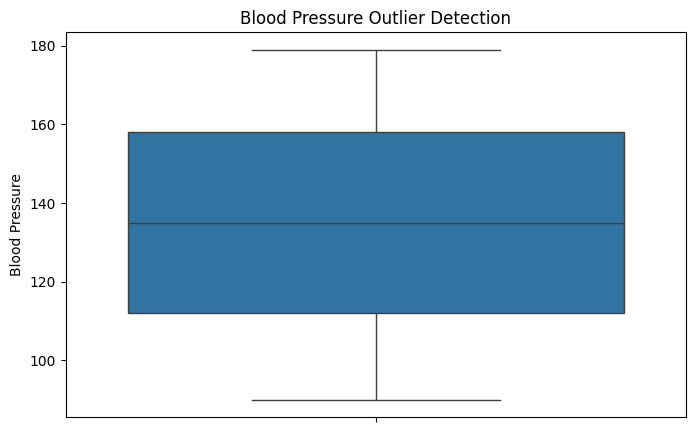

In [58]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["BloodPressure"])

plt.title("Blood Pressure Outlier Detection")
plt.ylabel("Blood Pressure")

plt.show()

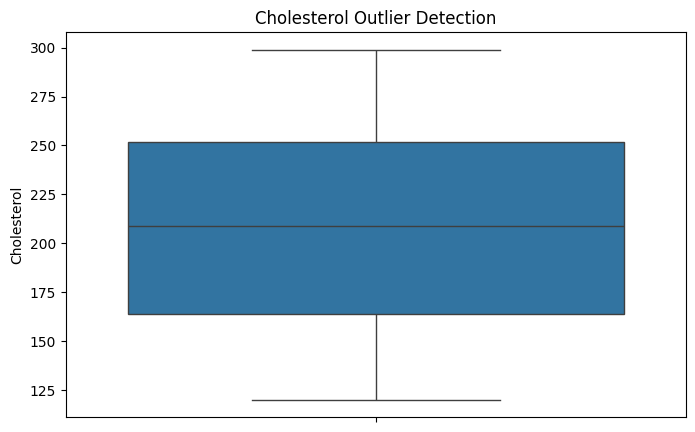

In [59]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Cholesterol"])

plt.title("Cholesterol Outlier Detection")
plt.ylabel("Cholesterol")

plt.show()

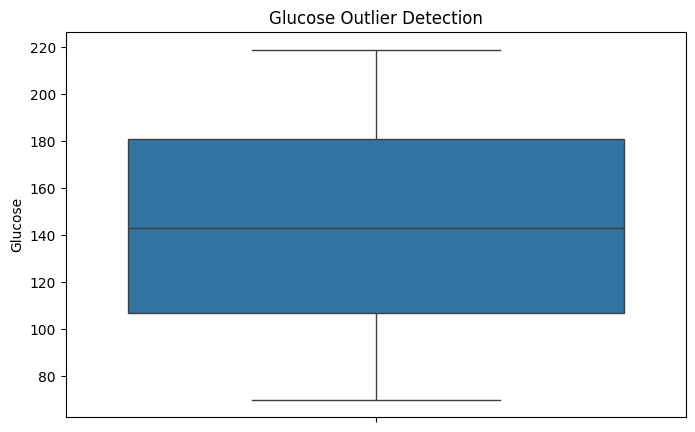

In [60]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Glucose"])

plt.title("Glucose Outlier Detection")
plt.ylabel("Glucose")

plt.show()

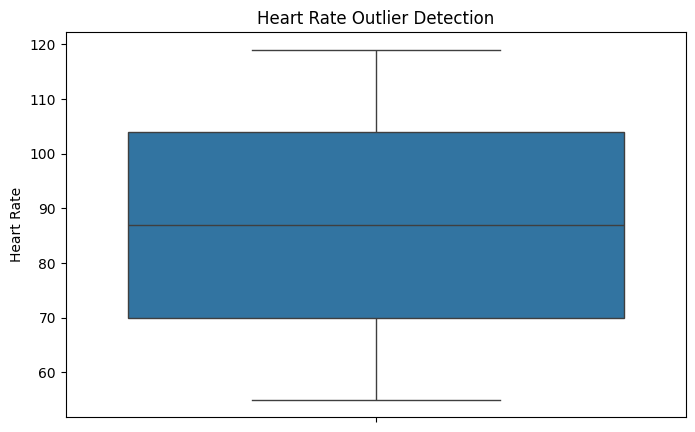

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["HeartRate"])

plt.title("Heart Rate Outlier Detection")
plt.ylabel("Heart Rate")

plt.show()

In [62]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    
    return outliers

In [63]:
detect_outliers(df, "BMI")

Column: BMI
Q1: 23.6
Q3: 34.625
IQR: 11.024999999999999
Lower Bound: 7.0625000000000036
Upper Bound: 51.162499999999994
Number of Outliers: 0


,Age,Gender,BMI,BloodPressure,Cholesterol,Glucose,Smoking,PhysicalActivity,FamilyHistory,HeartRate,Disease_Risk


In [64]:
detect_outliers(df, "BloodPressure")

Column: BloodPressure
Q1: 112.0
Q3: 158.0
IQR: 46.0
Lower Bound: 43.0
Upper Bound: 227.0
Number of Outliers: 0


,Age,Gender,BMI,BloodPressure,Cholesterol,Glucose,Smoking,PhysicalActivity,FamilyHistory,HeartRate,Disease_Risk
